## Baseline 
This is for the Project baseline, usas [] as model and get [] accuracy.

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [15]:
test_dataset = pd.read_csv(".\data\AI_Generated_Essays_Dataset.csv")
training_dataset = pd.read_csv(".\data\data_for_preprocessing.csv", index_col=0)
gen_ai_misinformation_set = pd.read_csv(".\data\generative_ai_misinformation_dataset.csv")

<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
<>:1: SyntaxWarning: invalid escape sequence '\d'
<>:2: SyntaxWarning: invalid escape sequence '\d'
<>:3: SyntaxWarning: invalid escape sequence '\d'
C:\Users\13893\AppData\Local\Temp\ipykernel_23492\3526458224.py:1: SyntaxWarning: invalid escape sequence '\d'
  test_dataset = pd.read_csv(".\data\AI_Generated_Essays_Dataset.csv")
C:\Users\13893\AppData\Local\Temp\ipykernel_23492\3526458224.py:2: SyntaxWarning: invalid escape sequence '\d'
  training_dataset = pd.read_csv(".\data\data_for_preprocessing.csv", index_col=0)
C:\Users\13893\AppData\Local\Temp\ipykernel_23492\3526458224.py:3: SyntaxWarning: invalid escape sequence '\d'
  gen_ai_misinformation_set = pd.read_csv(".\data\generative_ai_misinformation_dataset.csv")


## Data exploration

In [16]:
print(training_dataset.head)
print()
print(test_dataset.head)
print()
print(gen_ai_misinformation_set.head)

<bound method NDFrame.head of                                                    Text Author
0     This study investigates the chemical compositi...     AI
1     This study explores the cultural history of oi...     AI
2      Isolation of human peripheral blood mononucle...  Human
3      Dynamic Bayesian Networks (DBNs) are probabil...  Human
4      Within volleyball, performance analysis is em...  Human
...                                                 ...    ...
6064   Computational models serve as useful compleme...  Human
6065   During transport and storage of drinking wate...  Human
6066   The parameter values of neural networks will ...  Human
6067   Crumb Rubber Modified Asphalt (CRMA) offers a...  Human
6068  Generative AI for video is computationally exp...     AI

[6069 rows x 2 columns]>

<bound method NDFrame.head of                                                    text  generated
0     Machine learning, a subset of artificial intel...          1
1     A decision tree, 

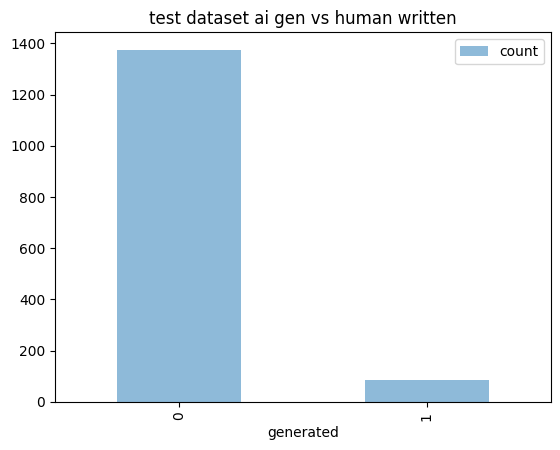

In [17]:

test_dataset['generated'].value_counts().plot(kind='bar', legend=True, alpha=.5)
plt.title("test dataset ai gen vs human written")
plt.show()

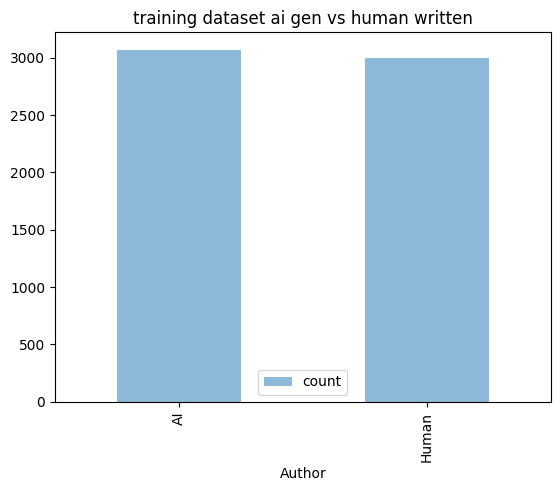

In [18]:

training_dataset['Author'].value_counts().plot(kind='bar', legend=True, alpha=.5)
plt.title("training dataset ai gen vs human written")
plt.show()

## Data Processing

In [25]:
label_mapping = {"human": 0, "ai": 1}
training_dataset['label'] = training_dataset['Author'].str.lower().map(label_mapping)

In [ ]:
# drop old mark
training_dataset = training_dataset.drop(columns=['Author'])
df = training_dataset
# 2. Quick look to confirm the shape and structure
print("--- Dataset Info ---")
print(f"Shape: {df.shape}")
print(df.head())

# 3. Check the class distribution (0 = Human, 1 = AI)
print("\n--- Class Distribution ---")
print(df['label'].value_counts())
print("\n--- Class Distribution (%) ---")
print((df['label'].value_counts(normalize=True) * 100).round(2))

# 4. Check for missing text data
print("\n--- Missing Values ---")
print(df.isnull().sum())

# 5. Analyze average text length
df['text_length'] = df['Text'].astype(str).apply(len)
print("\n--- Average Text Length by Class ---")
print(df.groupby('label')['text_length'].mean().round(2))

--- Dataset Info ---
Shape: (6069, 3)
                                                Text  label  text_length
0  This study investigates the chemical compositi...      1          132
1  This study explores the cultural history of oi...      1          156
2   Isolation of human peripheral blood mononucle...      0         2262
3   Dynamic Bayesian Networks (DBNs) are probabil...      0          878
4   Within volleyball, performance analysis is em...      0         1392

--- Class Distribution ---
label
1    3069
0    3000
Name: count, dtype: int64

--- Class Distribution (%) ---
label
1    50.57
0    49.43
Name: proportion, dtype: float64

--- Missing Values ---
Text           0
label          0
text_length    0
dtype: int64

--- Average Text Length by Class ---
label
0    1943.59
1     313.44
Name: text_length, dtype: float64


## Feature extraction

In [32]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    df['Text'], 
    df['label'], 
    test_size=0.2, 
    random_state=42,
    stratify=df['label']
)
print("--- Data Split ---")
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

--- Data Split ---
Training samples: 4855
Testing samples: 1214


In [77]:
vectorizer = TfidfVectorizer(
    max_features=10000, 
    ngram_range=(1, 2), 
    stop_words='english',
    min_df = 2
)

In [78]:
X_train_tfidf = vectorizer.fit_transform(X_train)

# ransform the TESTING data 
X_test_tfidf = vectorizer.transform(X_test)

# Review the results
print("\n--- Feature Extraction Complete ---")
print(f"Vocabulary size: {len(vectorizer.vocabulary_)}")
print(f"Training Feature Matrix Shape: {X_train_tfidf.shape}")
print(f"Testing Feature Matrix Shape: {X_test_tfidf.shape}")



--- Feature Extraction Complete ---
Vocabulary size: 10000
Training Feature Matrix Shape: (4855, 10000)
Testing Feature Matrix Shape: (1214, 10000)


## Model Build

In [39]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score, roc_auc_score, confusion_matrix

In [ ]:
# 1. Initialize the Baseline Classifier
baseline_model = LogisticRegression(max_iter=1000, random_state=42, C = 10, class_weight='balanced')

# 2. Train the Model
print("Training the baseline model...")
baseline_model.fit(X_train_tfidf, y_train)
print("Training complete!\n")

# 3. Make Predictions on the Test Set
y_pred = baseline_model.predict(X_test_tfidf)
y_pred_proba = baseline_model.predict_proba(X_test_tfidf)[:, 1]

# 4. Evaluate the Model
f1 = f1_score(y_test, y_pred)
auc_roc = roc_auc_score(y_test, y_pred_proba)

print("--- Evaluation Metrics ---")
print(f"F1-Score: {f1:.4f}")
print(f"AUC-ROC:  {auc_roc:.4f}\n")

# Detailed classification report (Precision, Recall, F1 for both classes)
print("--- Detailed Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Human (0)', 'AI (1)']))

# Confusion Matrix to see exactly where the model gets confused
print("--- Confusion Matrix ---")
cm = confusion_matrix(y_test, y_pred)
print(f"True Negatives (Human correctly identified): {cm[0][0]}")
print(f"False Positives (Human misclassified as AI): {cm[0][1]}")
print(f"False Negatives (AI misclassified as Human): {cm[1][0]}")
print(f"True Positives (AI correctly identified):    {cm[1][1]}")

Training the baseline model...
Training complete!

--- Evaluation Metrics ---
F1-Score: 0.9894
AUC-ROC:  0.9996

--- Detailed Classification Report ---
              precision    recall  f1-score   support

   Human (0)       0.99      0.99      0.99       600
      AI (1)       0.99      0.99      0.99       614

    accuracy                           0.99      1214
   macro avg       0.99      0.99      0.99      1214
weighted avg       0.99      0.99      0.99      1214

--- Confusion Matrix ---
True Negatives (Human correctly identified): 593
False Positives (Human misclassified as AI): 7
False Negatives (AI misclassified as Human): 6
True Positives (AI correctly identified):    608


## Evaluation

In [ ]:
df_eval = test_dataset.dropna(subset=['text'])

# 2. Extract features using the ALREADY FITTED vectorizer
X_eval_tfidf = vectorizer.transform(df_eval['text'])
y_eval_true = df_eval['generated']

# 3. Make Predictions using the ALREADY TRAINED baseline model
print("Evaluating baseline model on the first dataset...\n")
y_eval_pred = baseline_model.predict(X_eval_tfidf)
y_eval_pred_proba = baseline_model.predict_proba(X_eval_tfidf)[:, 1]

# 4. Calculate Evaluation Metrics
f1_eval = f1_score(y_eval_true, y_eval_pred)
auc_roc_eval = roc_auc_score(y_eval_true, y_eval_pred_proba)

print("--- Cross-Dataset Evaluation Metrics ---")
print(f"F1-Score: {f1_eval:.4f}")
print(f"AUC-ROC:  {auc_roc_eval:.4f}\n")

# Detailed classification report
print("--- Detailed Classification Report ---")
print(classification_report(y_eval_true, y_eval_pred, target_names=['Human (0)', 'AI (1)']))

# Confusion Matrix
print("--- Confusion Matrix ---")
cm_eval = confusion_matrix(y_eval_true, y_eval_pred)
print(f"True Negatives (Human correctly identified): {cm_eval[0][0]}")
print(f"False Positives (Human misclassified as AI): {cm_eval[0][1]}")
print(f"False Negatives (AI misclassified as Human): {cm_eval[1][0]}")
print(f"True Positives (AI correctly identified):    {cm_eval[1][1]}")

Evaluating baseline model on the first dataset...

--- Cross-Dataset Evaluation Metrics ---
F1-Score: 0.1534
AUC-ROC:  0.6283

--- Detailed Classification Report ---
              precision    recall  f1-score   support

   Human (0)       0.96      0.63      0.76      1375
      AI (1)       0.09      0.58      0.15        85

    accuracy                           0.63      1460
   macro avg       0.52      0.60      0.46      1460
weighted avg       0.91      0.63      0.73      1460

--- Confusion Matrix ---
True Negatives (Human correctly identified): 870
False Positives (Human misclassified as AI): 505
False Negatives (AI misclassified as Human): 36
True Positives (AI correctly identified):    49


## Fine Tuning

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline

In [ ]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(stop_words='english')),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

# 2. Define the Parameter Grid
# We are testing combinations specifically designed to STOP overfitting.
param_grid = {
    # TF-IDF Parameters
    'tfidf__max_features': [10000],  # Restrict the vocabulary size
    'tfidf__min_df': [1, 2],                 # Ignore words that appear in fewer than X documents (removes highly specific quirks)
    'tfidf__ngram_range': [(1, 2), (1,3), (2,3)],      # Test if single words generalize better than two-word phrases
    
    # Logistic Regression Parameters
    'clf__C': [1.0, 5.0, 10.0]             # Regularization (Lower C = stronger penalty against memorizing specific weights)
}

# 3. Initialize Grid Search
# cv=5 means 5-fold cross-validation. scoring='f1' tells it to optimize for the best F1-score.
print("Initializing Grid Search. This will test", 
      len(param_grid['tfidf__max_features']) * len(param_grid['tfidf__min_df']) * len(param_grid['tfidf__ngram_range']) * len(param_grid['clf__C']), 
      "combinations...")

grid_search = GridSearchCV(
    pipeline, 
    param_grid, 
    cv=5, 
    scoring='f1', 
    n_jobs=-1,  # Uses all available CPU cores to speed this up
    verbose=1
)

# 4. Run the Grid Search on the TRAINING data (the 6000-row dataset)
# (Assuming X_train and y_train are still in memory from the previous steps)
print("Running Grid Search...")
grid_search.fit(X_train, y_train)

# 5. Review the Best Parameters
print("\n--- Best Parameters Found ---")
for param_name in sorted(param_grid.keys()):
    print(f"{param_name}: {grid_search.best_params_[param_name]}")

print(f"Best Cross-Validation F1-Score: {grid_search.best_score_:.4f}")

# 6. Extract the Best Model
best_model = grid_search.best_estimator_

# ==========================================
# 7. THE REAL TEST: Evaluate on the Unseen Dataset
# ==========================================
print("\nEvaluating the OPTIMIZED baseline on the unseen (1460-row) dataset...")

# (Assuming df_eval is still in memory from our previous cross-dataset test)
y_eval_true = df_eval['generated']
X_eval = df_eval['text']

# Use the best model to predict directly (the pipeline handles the TF-IDF transform automatically)
y_eval_pred = best_model.predict(X_eval)
y_eval_pred_proba = best_model.predict_proba(X_eval)[:, 1]

f1_eval_opt = f1_score(y_eval_true, y_eval_pred)
auc_roc_eval_opt = roc_auc_score(y_eval_true, y_eval_pred_proba)

print("\n--- Optimized Cross-Dataset Metrics ---")
print(f"F1-Score: {f1_eval_opt:.4f}")
print(f"AUC-ROC:  {auc_roc_eval_opt:.4f}")